In [1]:
from gradio.monitoring_dashboard import total_requests
from rich.jupyter import display
from timm.models.swin_transformer_v2_cr import init_weights
from torch.amp import custom_bwd
from torch.nn.functional import threshold
from transformers.models.x_clip.modeling_x_clip import x_clip_loss
%load_ext autoreload
%autoreload 2

C:\Users\jimmy\PycharmProjects\FoodPhotoEnhancer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import logging
from pathlib import Path

import plt
import torch

from core.constants import Constants
from core.settings import DinoDetectorSettings, SamSegmenterSettings, DepthAnythingV2Settings
from image_utils import ImageUtils
from subject_pipeline import SubjectIsolationPipeline

logging.basicConfig(level=logging.DEBUG,
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    datefmt='%Y-%m-%d %H:%M')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
logging.info(f"DEVICE: {DEVICE}")

dino_settings = DinoDetectorSettings(
    model_config_path="groundingdino/config/GroundingDINO_SwinT_OGC.py",
    model_checkpoint_path="checkpoints/groundingdino_swint_ogc.pth",
    grounding_prompt=Constants.GROUNDING_PROMPT,
    box_threshold=0.3,
    text_threshold=0.25,
)

sam_settings = SamSegmenterSettings(
    checkpoint="checkpoints/sam_vit_b_01ec64.pth",
    sam_model_type="vit_b",
)

depth_settings = DepthAnythingV2Settings(
    encoder="vits",
    features=64,
    out_channels=(48, 96, 192, 384),
    checkpoint_path="checkpoints/depth_anything_v2_vits.pth",
)

pipeline = SubjectIsolationPipeline(
    device=DEVICE,
    dino_settings=dino_settings,
    sam_segmenter_settings=sam_settings,
    depth_anything_settings=depth_settings,
)

run_folder = False
if run_folder:
    folder_path = Path("photos")
    for file_path in folder_path.iterdir():
        if file_path.is_file():
            subject_region, total_depth, dmin, dmax, image_source = pipeline.find_subject(file_path)
            ImageUtils.show_mask_depth(
                mask=subject_region.mask,
                image_source_depth=total_depth,
                vmin=dmin,
                vmax=dmax,
                title=f"Current region"
            )
else:
    file_path = Path("photos/good_light_1.png")
    subject_region, total_depth, dmin, dmax, image_source = pipeline.find_subject(file_path)

C:\Users\jimmy\PycharmProjects\FoodPhotoEnhancer\.venv\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
xFormers not available
xFormers not available
C:\Users\jimmy\PycharmProjects\FoodPhotoEnhancer\.venv\Lib\site-packages\torch\cuda\__init__.py:129: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 1: invalid argument (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10\cuda\CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
2025-12-28 14:28 - INFO - DEVICE: cpu
2025-12-28 14:28 - INFO - Initializing SubjectIsolationPipeline
2025-12-28 14:28 - DEBUG - Loading Grounding DINO model
C:\Users\jimmy

final text_encoder_type: bert-base-uncased


2025-12-28 14:28 - DEBUG - https://huggingface.co:443 "HEAD /bert-base-uncased/resolve/main/tokenizer_config.json HTTP/1.1" 200 0
2025-12-28 14:28 - DEBUG - https://huggingface.co:443 "GET /api/models/bert-base-uncased/tree/main/additional_chat_templates?recursive=False&expand=False HTTP/1.1" 307 141
2025-12-28 14:28 - DEBUG - https://huggingface.co:443 "GET /api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=False&expand=False HTTP/1.1" 404 64
2025-12-28 14:28 - DEBUG - https://huggingface.co:443 "GET /api/models/bert-base-uncased/tree/main?recursive=True&expand=False HTTP/1.1" 307 114
2025-12-28 14:28 - DEBUG - https://huggingface.co:443 "GET /api/models/google-bert/bert-base-uncased/tree/main?recursive=True&expand=False HTTP/1.1" 200 3937
2025-12-28 14:28 - DEBUG - https://huggingface.co:443 "HEAD /bert-base-uncased/resolve/main/config.json HTTP/1.1" 200 0
2025-12-28 14:28 - DEBUG - https://huggingface.co:443 "HEAD /bert-base-uncased/resolve/main/

2025-12-28 14:29 - INFO - pipeline:start
2025-12-28 14:29 - INFO - mask:fill_holes
2025-12-28 14:29 - DEBUG - mask_filled stats | min=0.000 max=1.000 mean=0.551
2025-12-28 14:29 - INFO - mask:soften
2025-12-28 14:29 - DEBUG - mask_soft shape=(1200, 1600, 1)
2025-12-28 14:29 - INFO - subject:enhance
2025-12-28 14:29 - DEBUG - subject stats | min=0.000 max=1.000 mean=0.565
2025-12-28 14:29 - INFO - background:blur
2025-12-28 14:29 - INFO - composite:blend
2025-12-28 14:29 - DEBUG - final stats | min=0.000 max=1.000 mean=0.531
2025-12-28 14:29 - INFO - pipeline:done
2025-12-28 14:29 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-12-28 14:29 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-12-28 14:29 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2025-12-28 14:29 - DEBUG - findfont: score(FontEntry(fname='C:\\Users\\jimmy\\PycharmProjects\\FoodPho

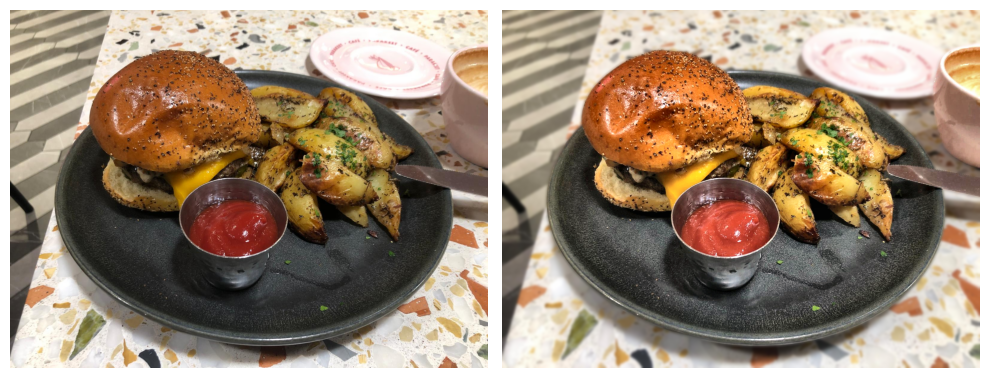

In [3]:
from enhancement_pipeline import EnhancementPipeline

pipeline = EnhancementPipeline(
    image=image_source,
    mask=subject_region.mask
)

final, clean_mask = pipeline.run()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_source)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(final)
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- INPUTS FROM YOUR PIPELINE ---
mask = subject_region.mask  # HxW, values {0,1} or {0,255}
image = image_source  # HxWx3, uint8 or float

# --- NORMALIZE IMAGE ---
if image.dtype != np.float32:
    image = image.astype(np.float32) / 255.0

# --- NORMALIZE MASK ---
mask = mask.astype(np.float32)
mask = mask / mask.max()  # ensure [0,1]

# --- FILL HOLES IN MASK ---
# --- PREP ---
mask_u8 = (mask * 255).astype(np.uint8)

# --- STEP 1: CLOSE SMALL GAPS (CRITICAL) ---
kernel = np.ones((7, 7), np.uint8)
mask_closed = cv2.morphologyEx(
    mask_u8,
    cv2.MORPH_CLOSE,
    kernel
)

# --- STEP 2: FLOOD FILL BACKGROUND ---
h, w = mask_closed.shape
flood = mask_closed.copy()
cv2.floodFill(flood, None, (0, 0), 255)

# --- STEP 3: FILL HOLES ---
mask_filled = mask_closed | cv2.bitwise_not(flood)

# --- FINAL ---
mask = mask_filled.astype(np.float32) / 255.0

#
# mask_u8 = (mask * 255).astype(np.uint8)
#
# contours, _ = cv2.findContours(
#     mask_u8,
#     cv2.RETR_EXTERNAL,
#     cv2.CHAIN_APPROX_SIMPLE
# )
#
# largest = max(contours, key=cv2.contourArea)
#
# mask_filled = np.zeros_like(mask_u8)
# cv2.drawContours(mask_filled, [largest], -1, 255, thickness=-1)

mask = mask_filled.astype(np.float32) / 255.0


plt.imshow(mask)
plt.axis('off')
plt.show()

# --- SOFTEN MASK EDGES ---
mask_soft = cv2.GaussianBlur(mask, (0, 0), sigmaX=3)
mask_soft = mask_soft[..., None]  # HxWx1


# ================================
# WINDOW LIGHT FUNCTION
# ================================
def apply_window_light(rgb_image, gamma=0.92):
    img_u8 = (rgb_image * 255.0).astype(np.uint8)

    lab = cv2.cvtColor(img_u8, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)

    L = L.astype(np.float32) / 255.0
    L = np.power(L, gamma)
    L = np.clip(L, 0.0, 1.0)
    L = (L * 255.0).astype(np.uint8)

    lab = cv2.merge([L, A, B])
    rgb_out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    return rgb_out.astype(np.float32) / 255.0


def apply_clahe_texture(rgb_image, clip_limit=1.5, strength=0.35):
    img_u8 = (rgb_image * 255.0).astype(np.uint8)

    lab = cv2.cvtColor(img_u8, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=(8, 8)
    )

    L_clahe = clahe.apply(L)

    # blend CLAHE back gently
    L_out = cv2.addWeighted(L, 1.0 - strength, L_clahe, strength, 0)

    lab_out = cv2.merge([L_out, A, B])
    rgb_out = cv2.cvtColor(lab_out, cv2.COLOR_LAB2RGB)

    return rgb_out.astype(np.float32) / 255.0


# ================================
# SUBJECT ENHANCEMENT (70–80%)
# ================================
enhanced = image.copy()

# 1. Exposure (conservative)
enhanced *= 1.15

# 2. Warm white balance
enhanced[..., 0] *= 1.03
enhanced[..., 2] *= 0.97

enhanced = np.clip(enhanced, 0.0, 1.0)

# 3. Window light (luminance only)
enhanced = apply_window_light(enhanced, gamma=0.85)

# 4. Gentle contrast (after window light)
mean = enhanced.mean(axis=(0, 1), keepdims=True)
enhanced = enhanced + 0.05 * (enhanced - mean)

# 5. Mild saturation
gray = np.mean(enhanced, axis=2, keepdims=True)
enhanced = gray + 1.04 * (enhanced - gray)

enhanced = np.clip(enhanced, 0.0, 1.0)

# ================================
# BACKGROUND QUIETING + COOLING
# ================================
background = cv2.GaussianBlur(image, (0, 0), sigmaX=4, sigmaY=4)

# ================================
# CLAHE
# ================================

enhanced = apply_clahe_texture(
    enhanced,
    clip_limit=3.5,
    strength=0.4
)

# ================================
# FINAL COMPOSITE
# ================================
final = mask_soft * enhanced + (1.0 - mask_soft) * background

# ================================
# DISPLAY
# ================================
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(final)
plt.title("Enhanced (MVP)")
plt.axis("off")

plt.tight_layout()
plt.show()
